## USD MS-ADS 502

## Jacob Moore and Jordyn Gonzales

## Team 5 Final Project

## EDA

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [23]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features 
y = predict_students_dropout_and_academic_success.data.targets 
  
# metadata 
print(predict_students_dropout_and_academic_success.metadata) 
  
# variable information 
print(predict_students_dropout_and_academic_success.variables) 

#this is from https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success by importing in python

{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [24]:
df = pd.concat([X, y], axis = 1)
df
#create a dataframe that has the predictors and target variables

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [26]:
df.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


**Note that most of the variables are categorical and encoded as integers, so it would be better to look at comparisons acorss categories**

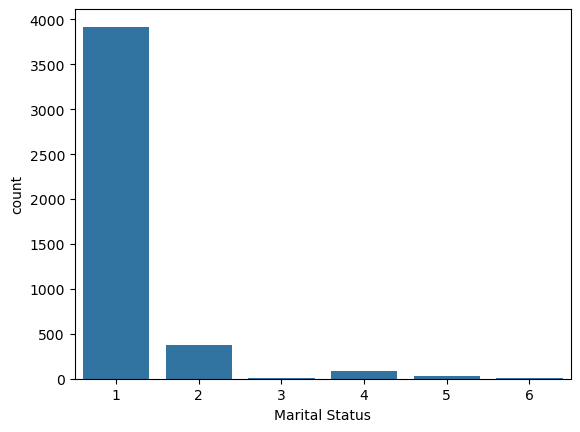

In [27]:
sns.countplot(x='Marital Status', data=df)
plt.show()

C:\Users\jrmoo\AppData\Local\Temp\ipykernel_15324\1276639796.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


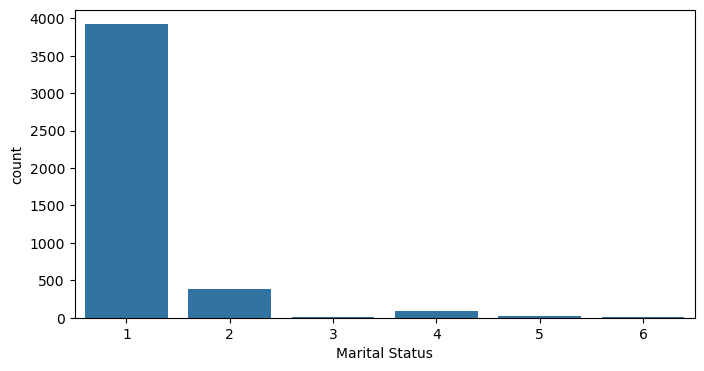

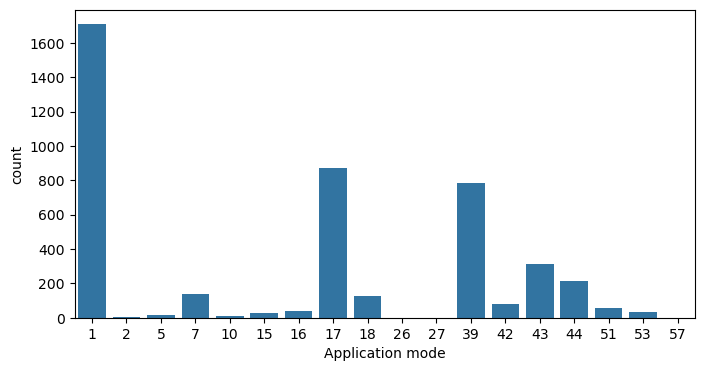

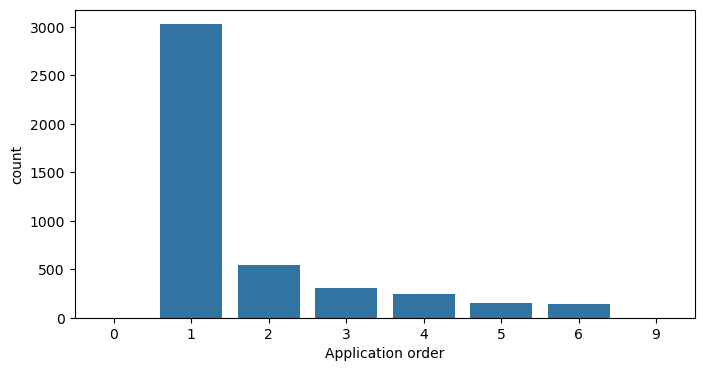

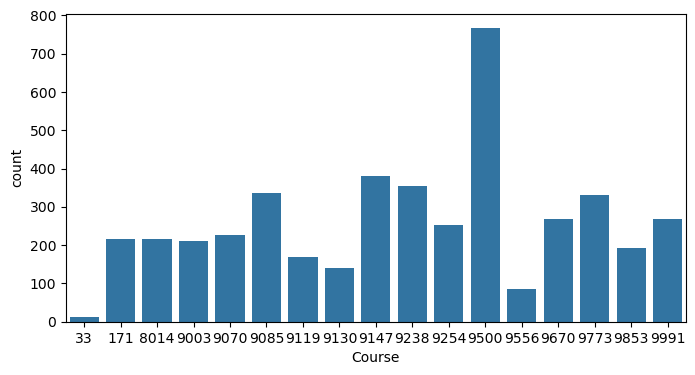

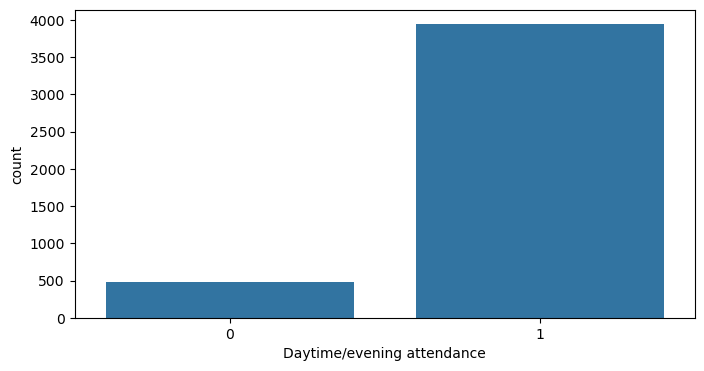

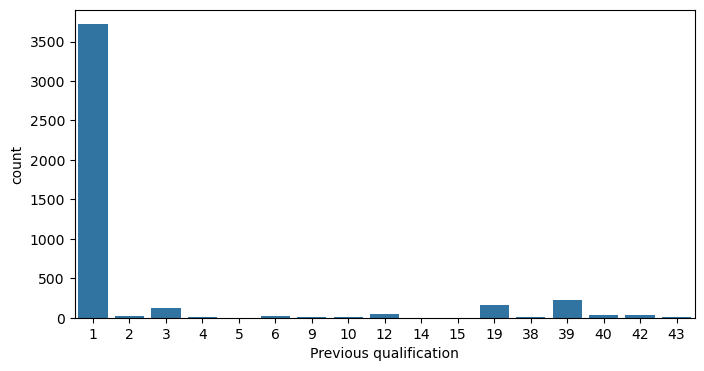

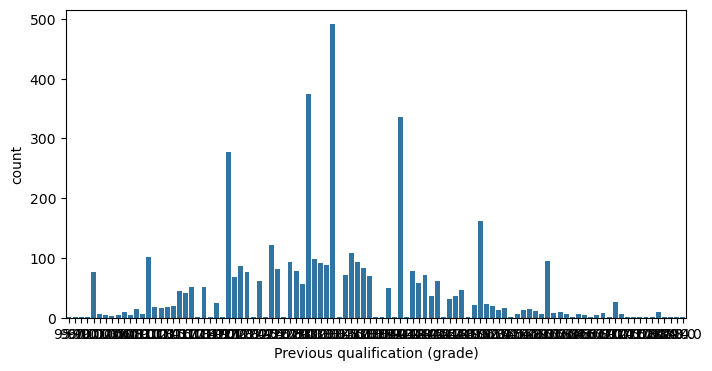

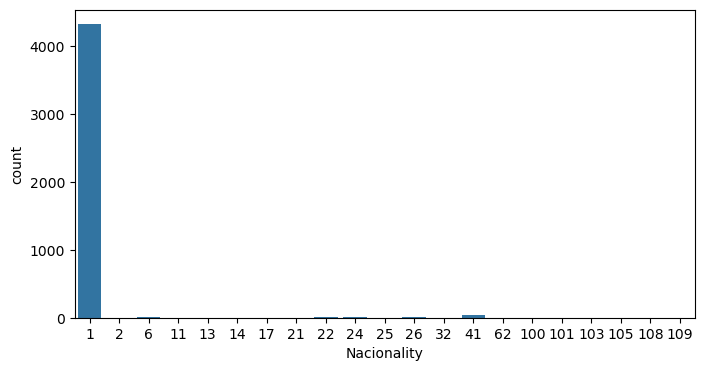

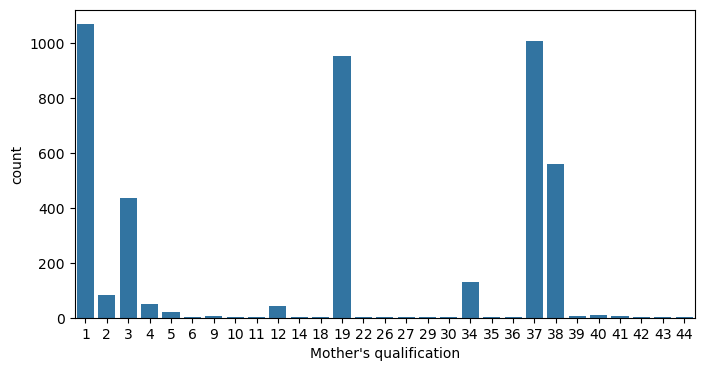

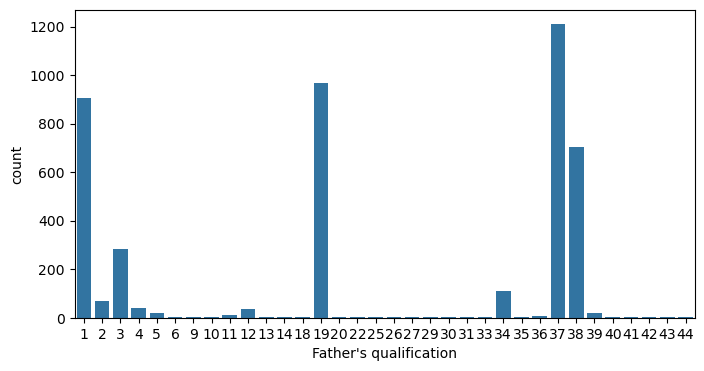

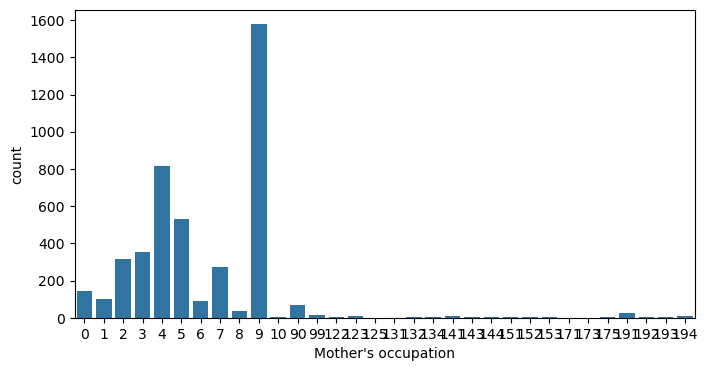

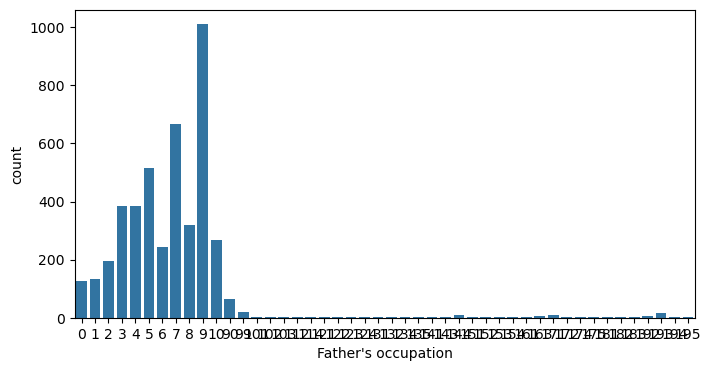

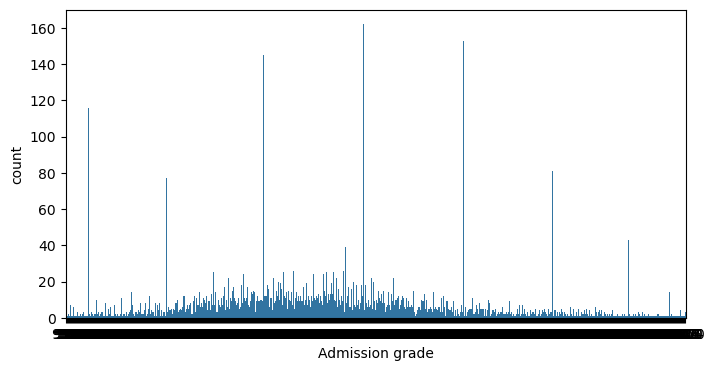

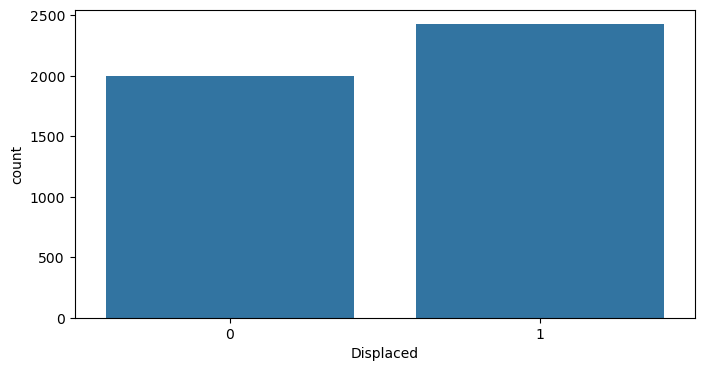

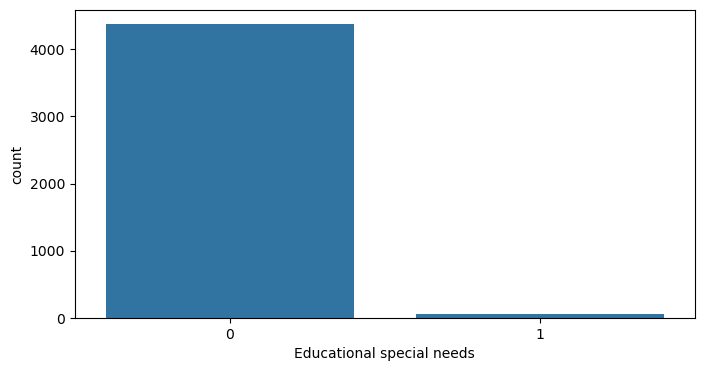

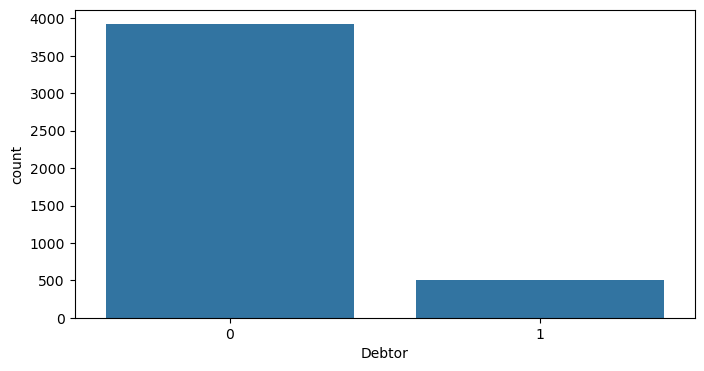

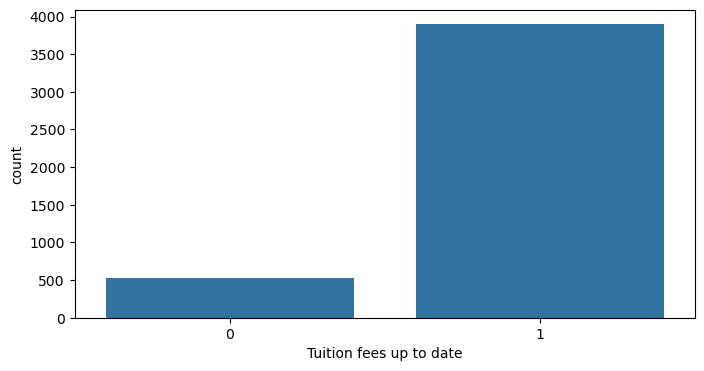

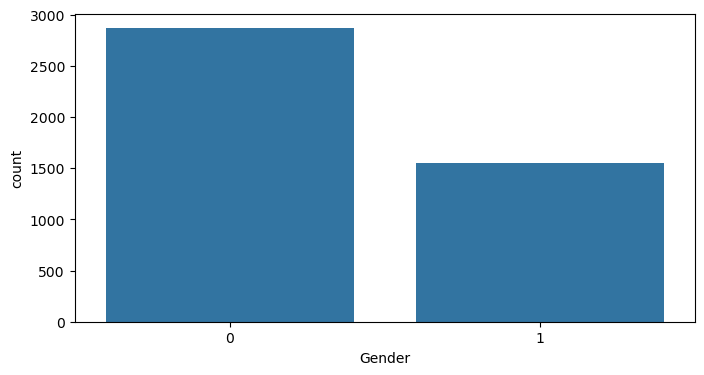

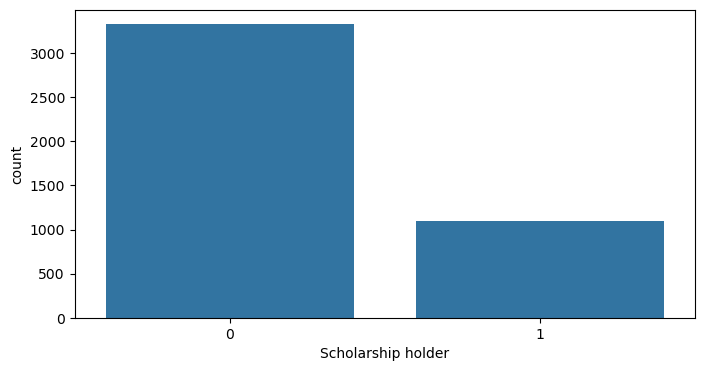

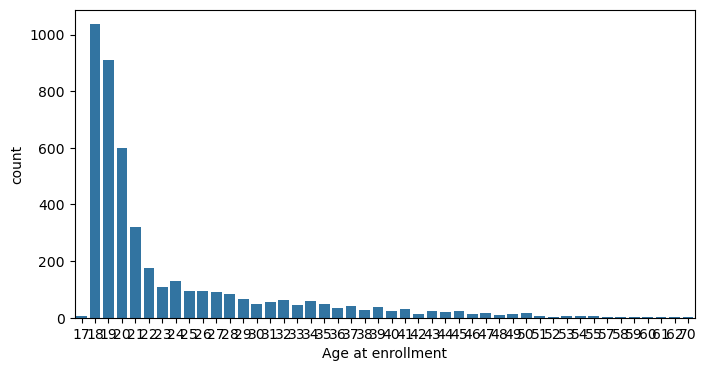

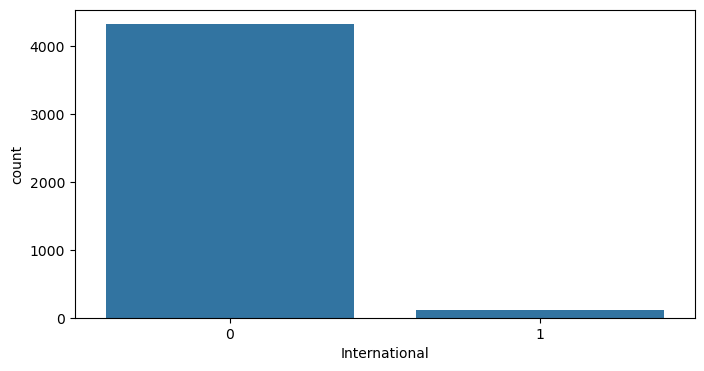

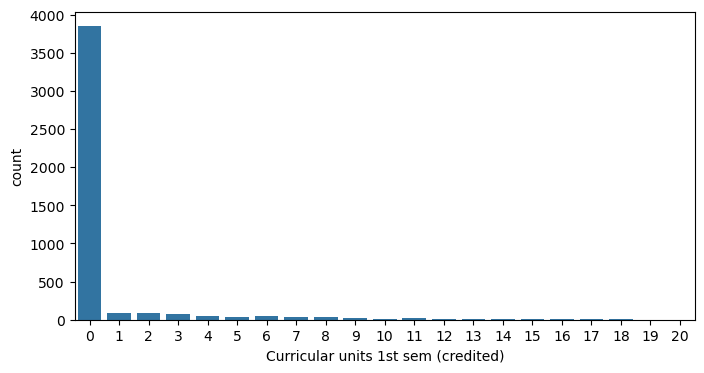

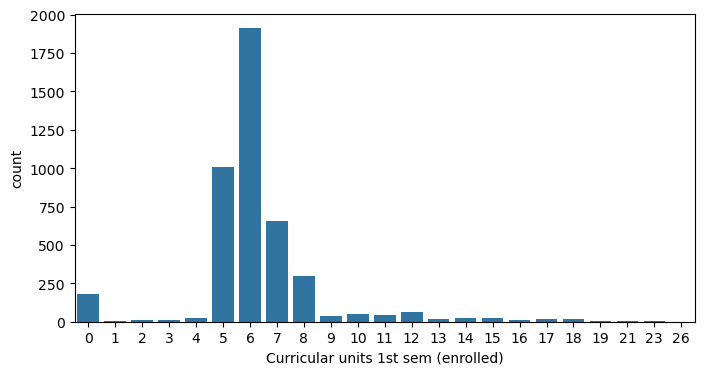

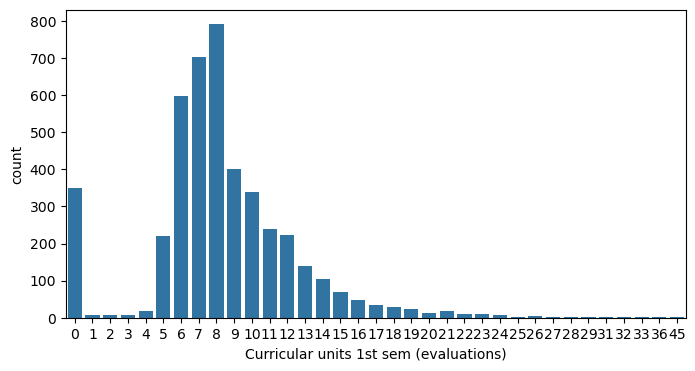

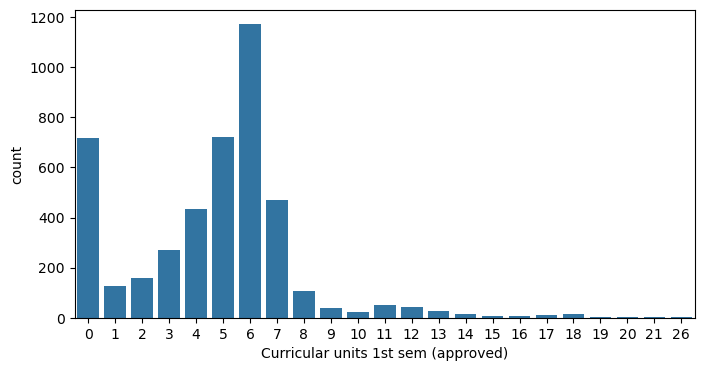

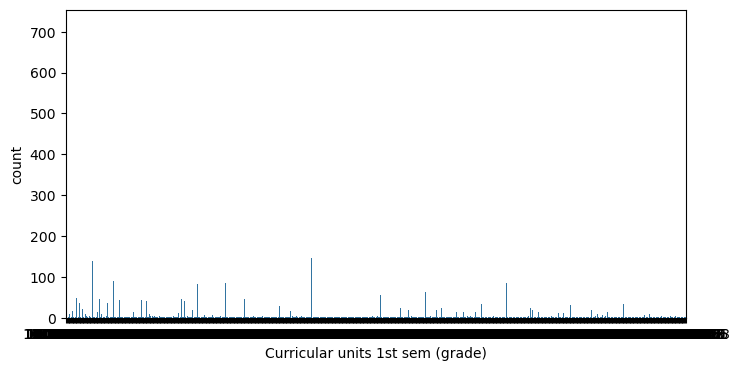

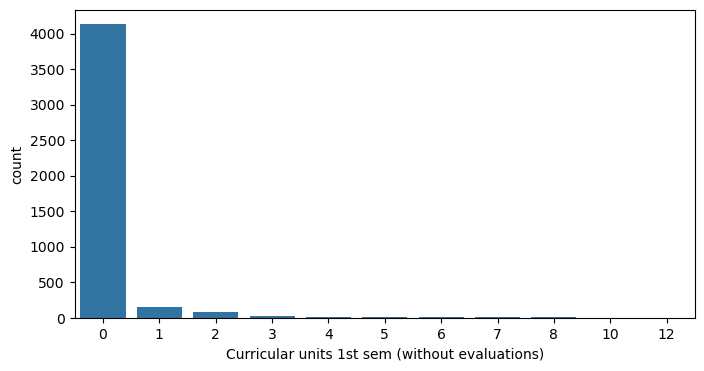

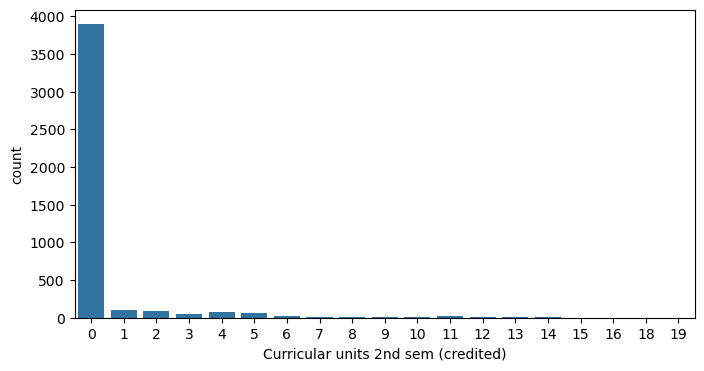

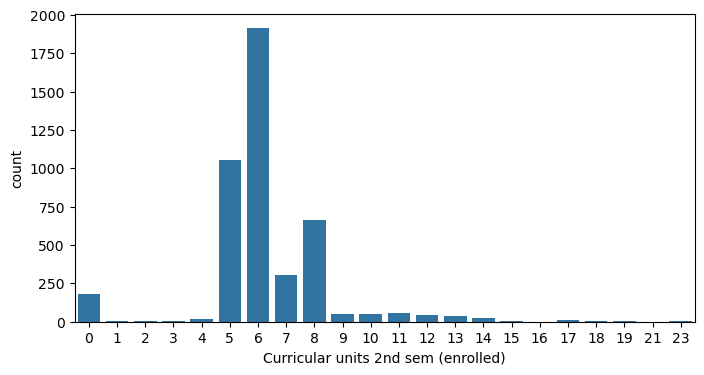

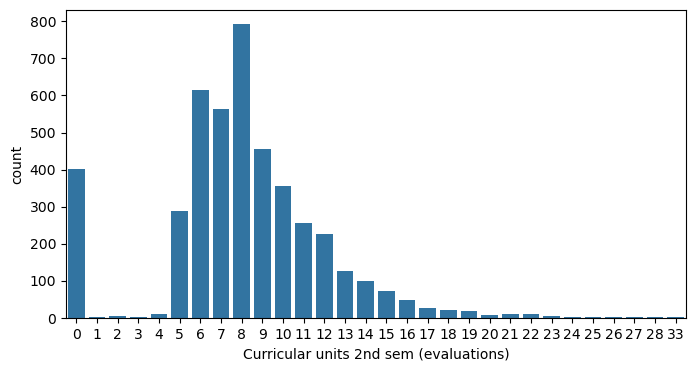

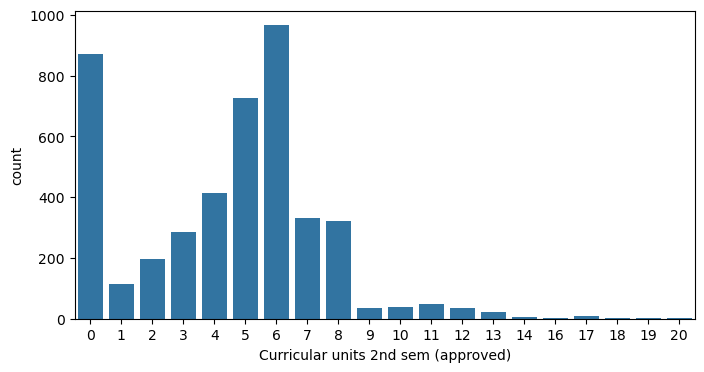

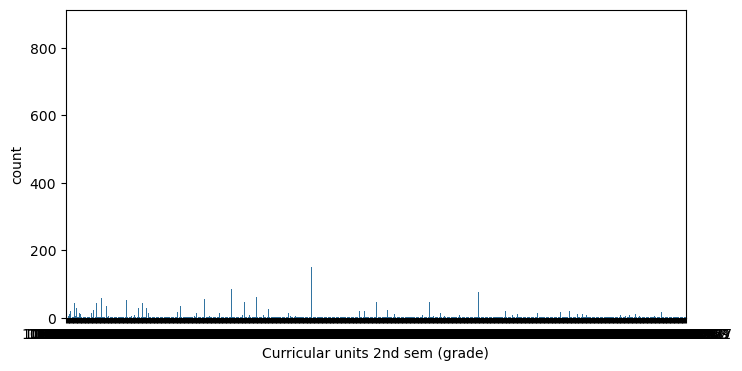

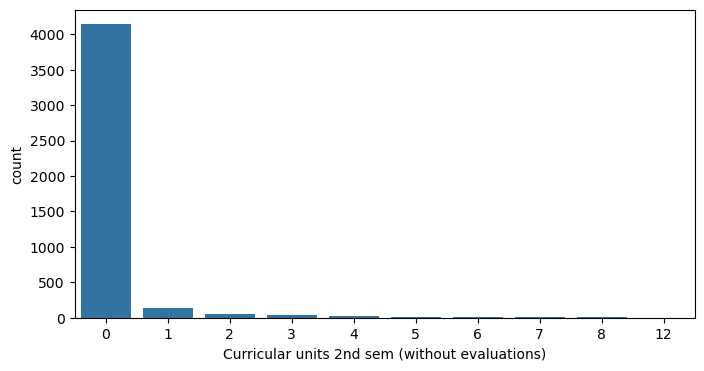

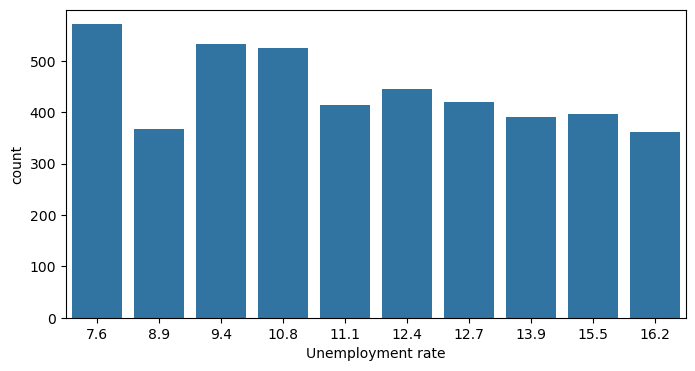

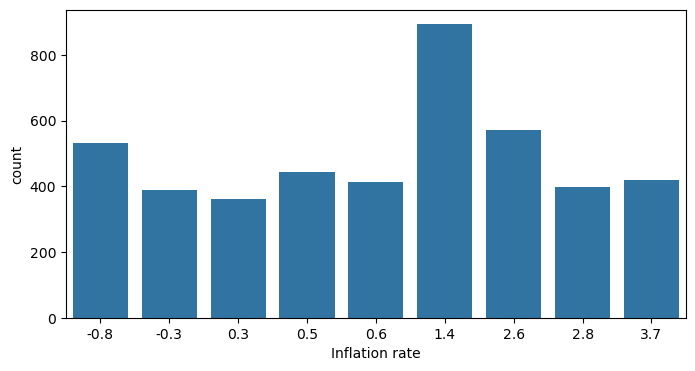

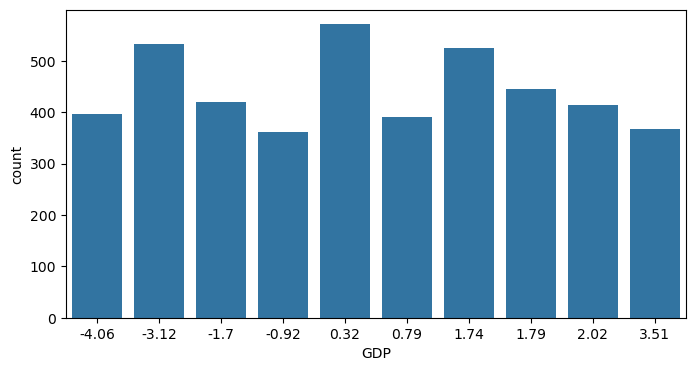

In [28]:
for x in X:
    plt.figure(figsize=(8,4))
    sns.countplot(x=x, data=df)

C:\Users\jrmoo\AppData\Local\Temp\ipykernel_15324\3475675106.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,4))


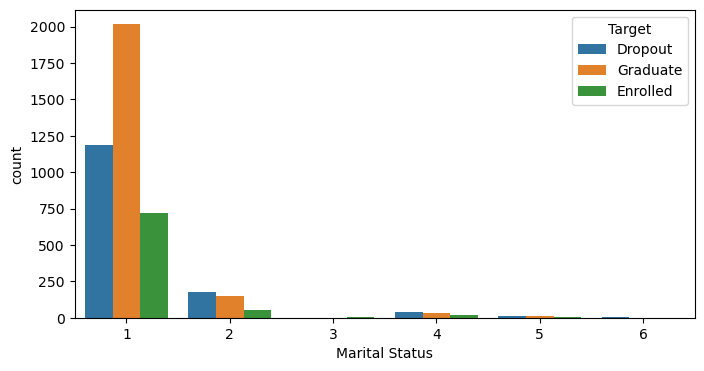

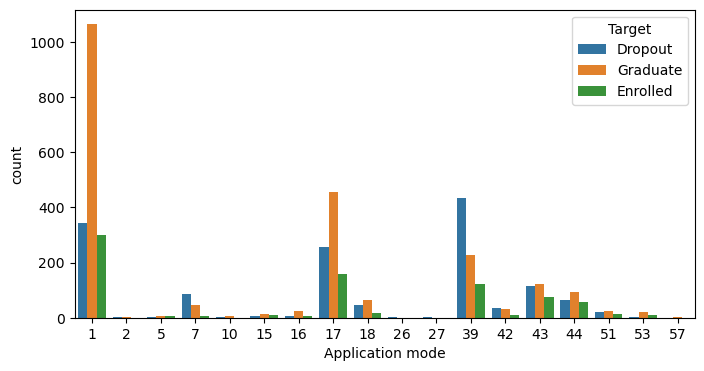

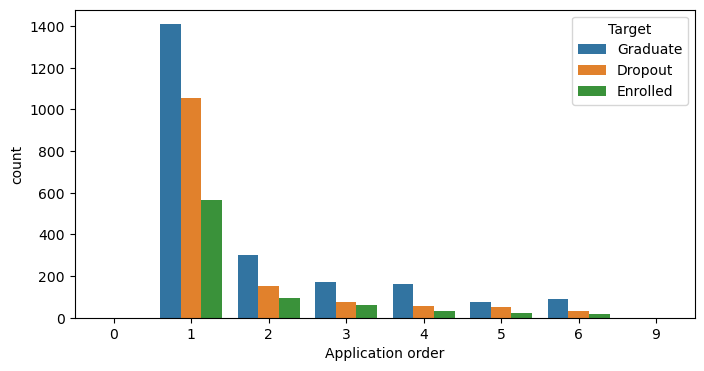

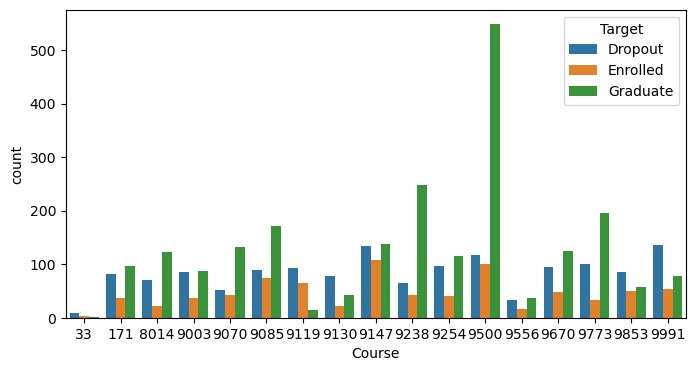

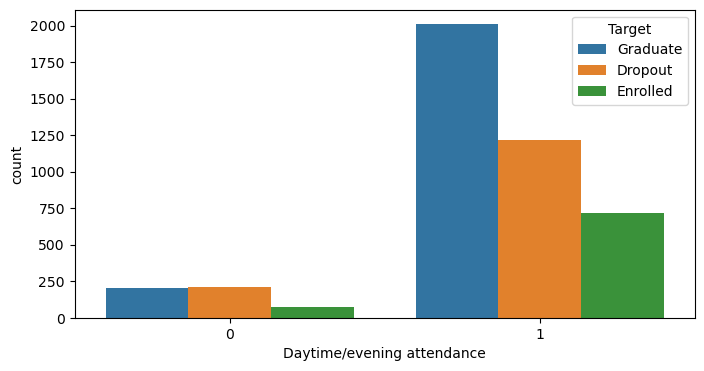

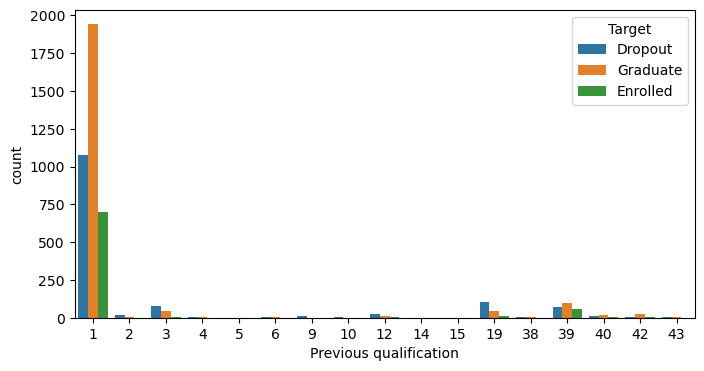

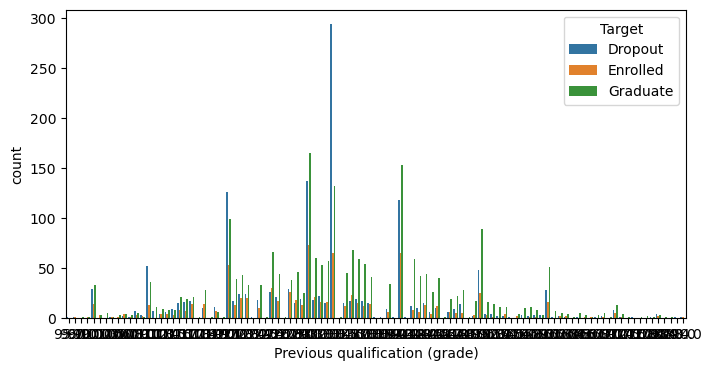

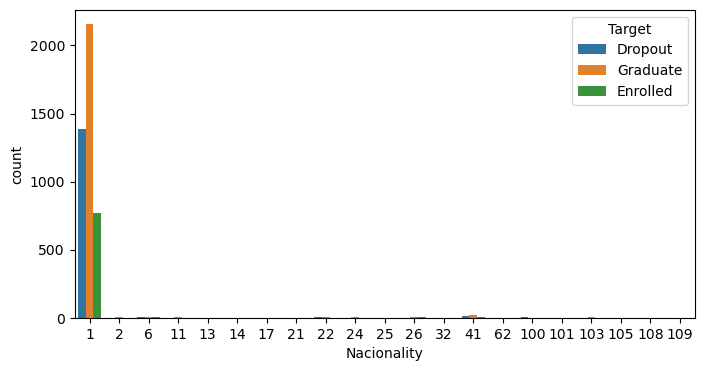

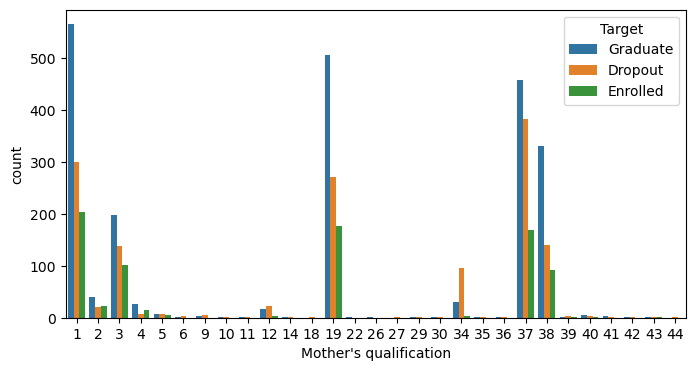

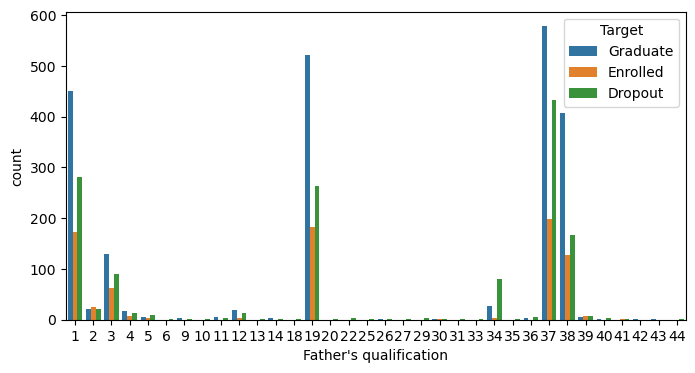

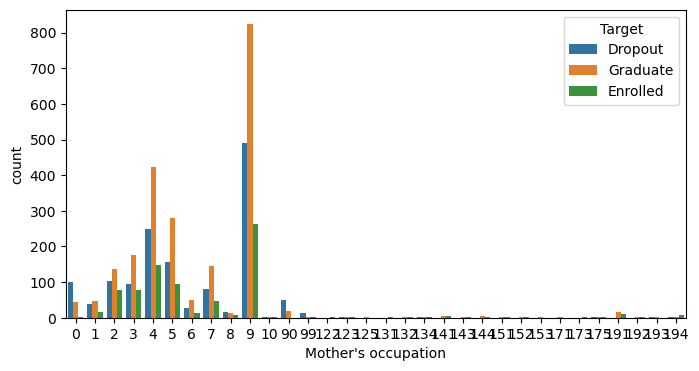

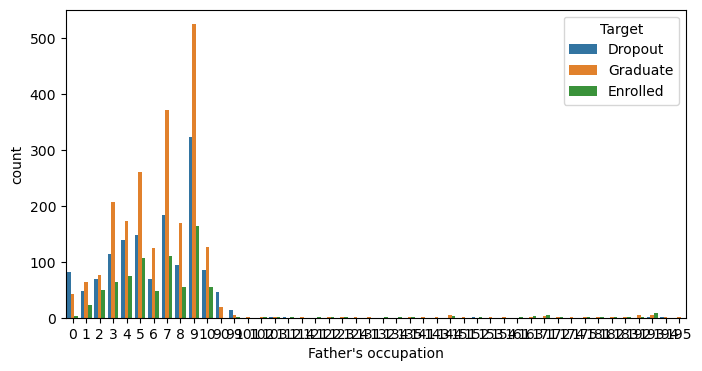

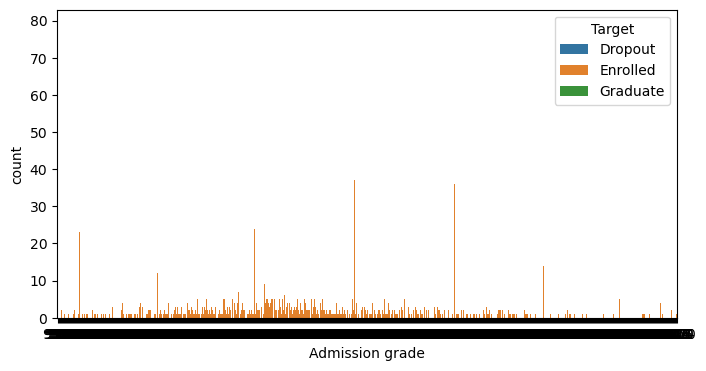

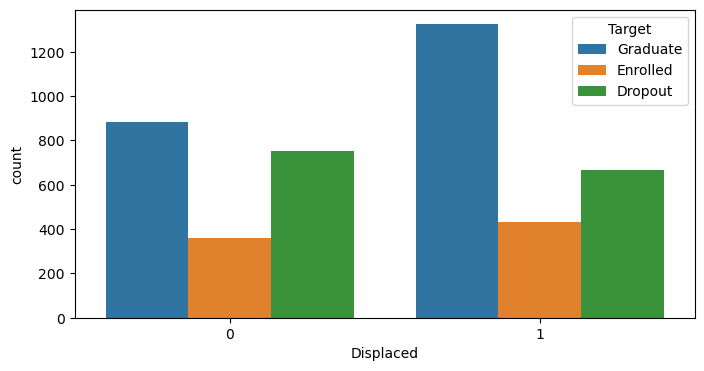

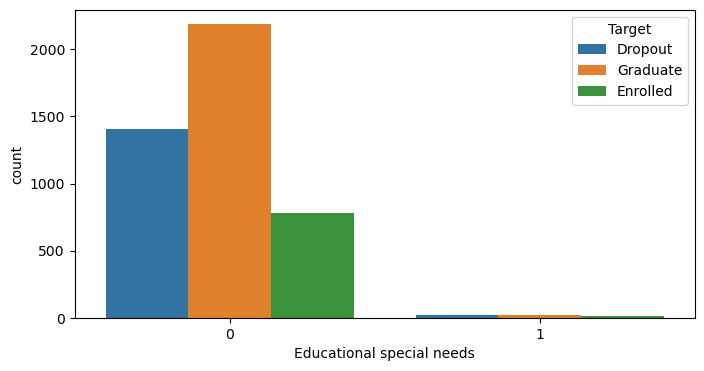

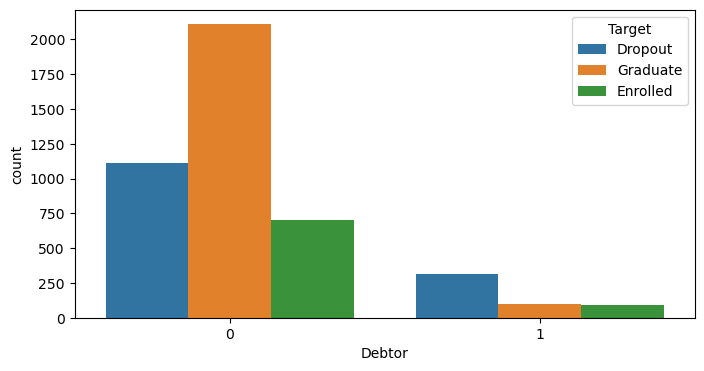

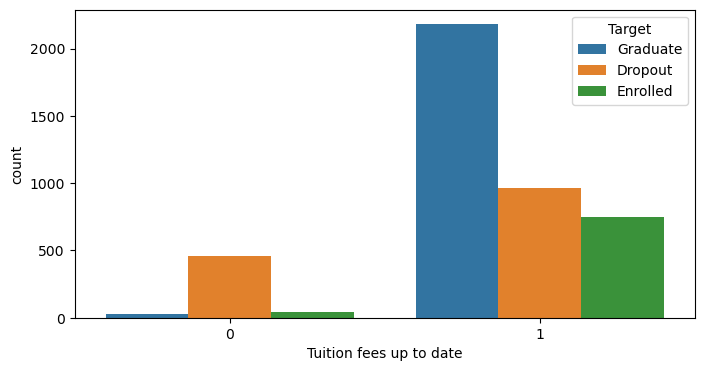

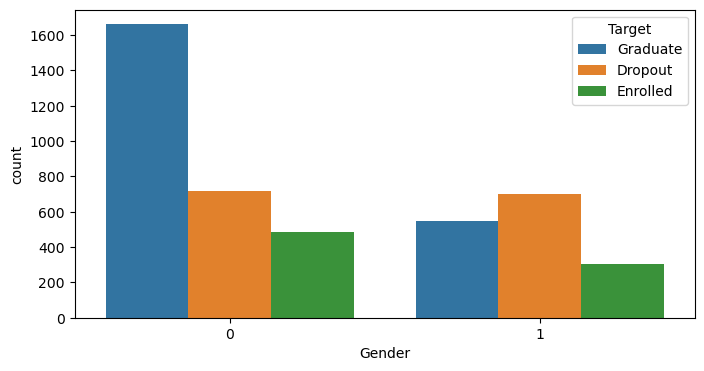

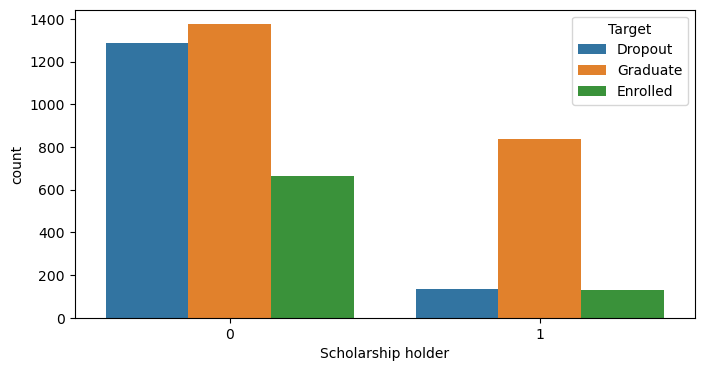

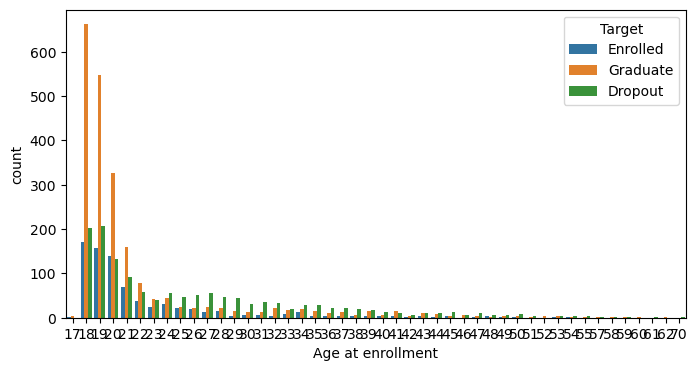

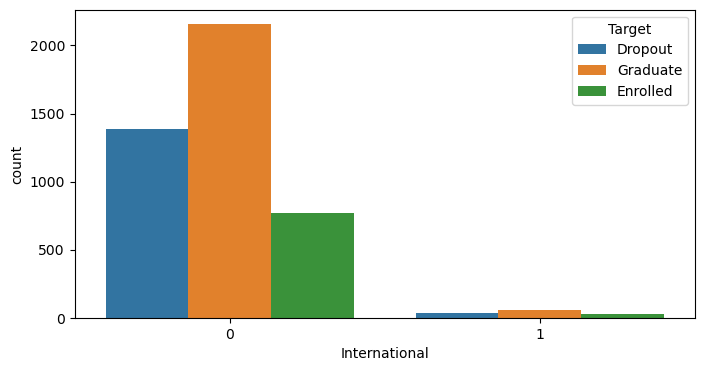

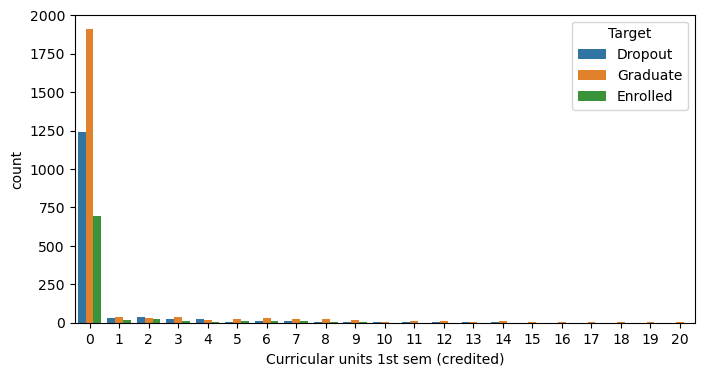

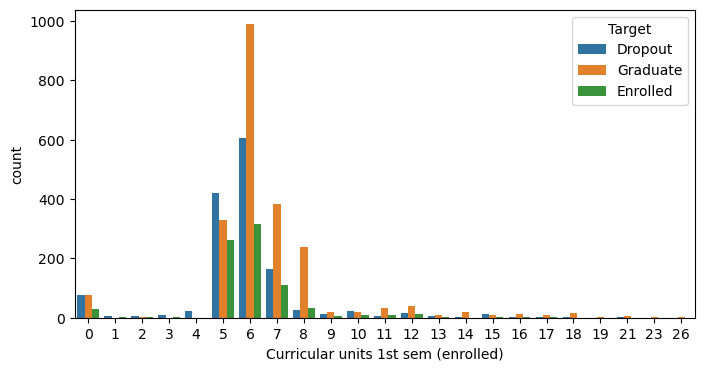

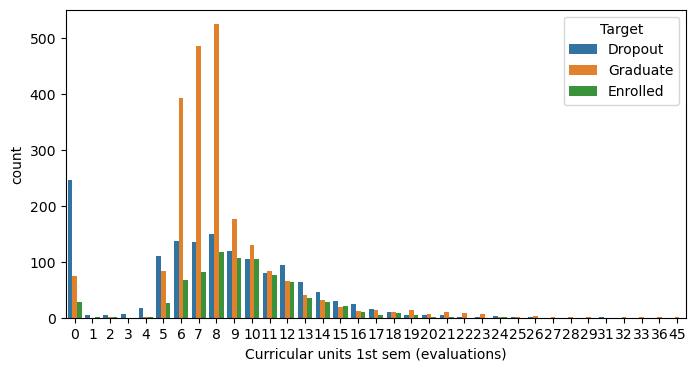

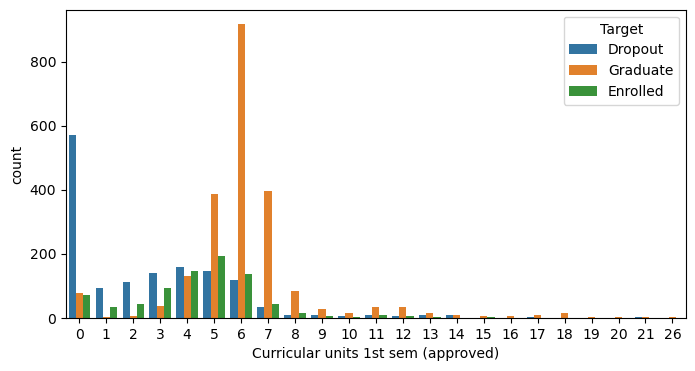

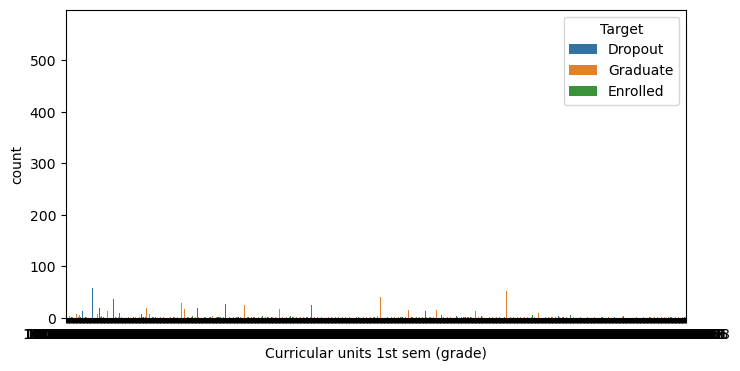

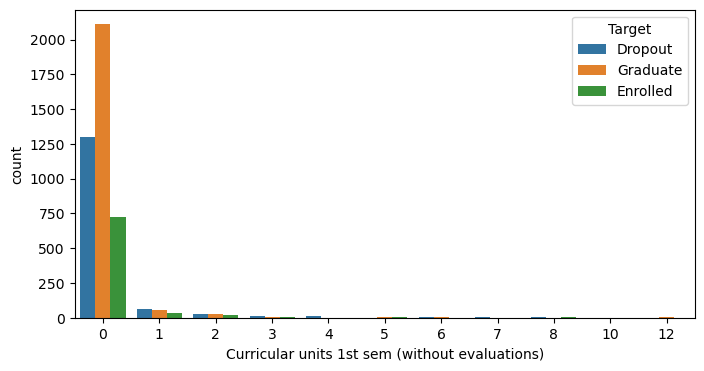

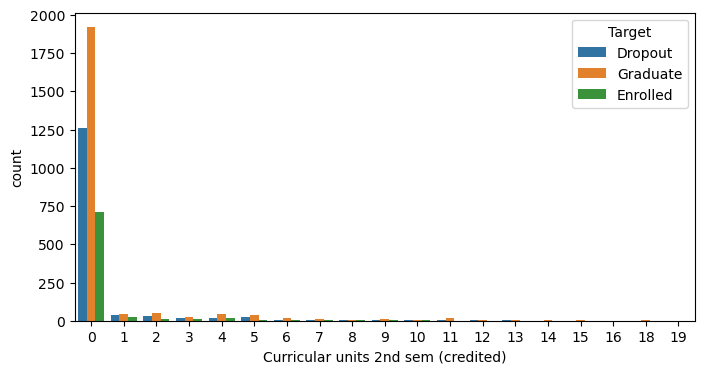

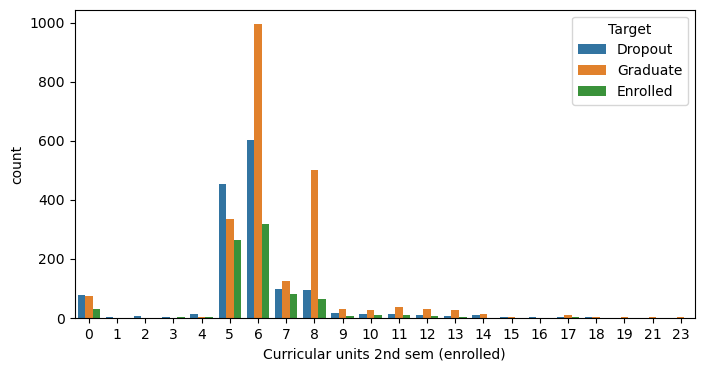

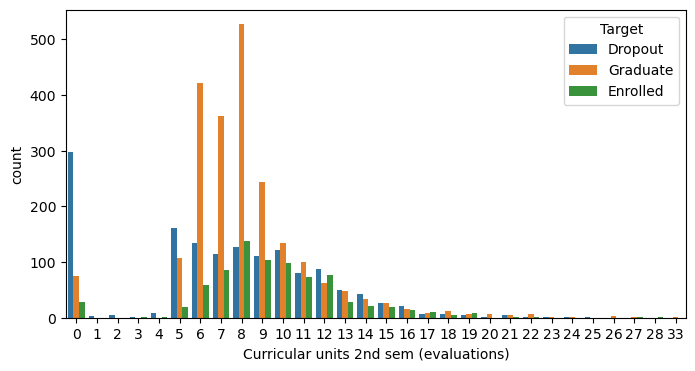

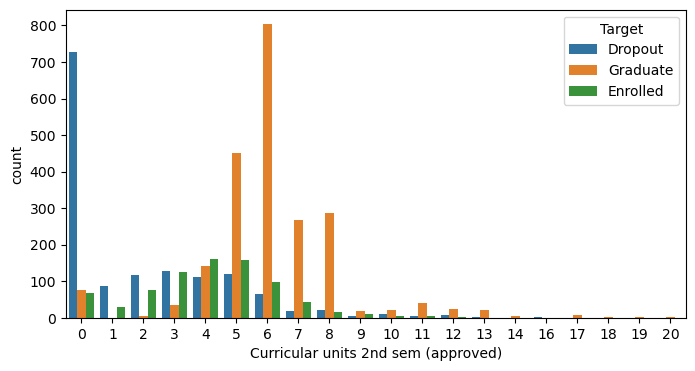

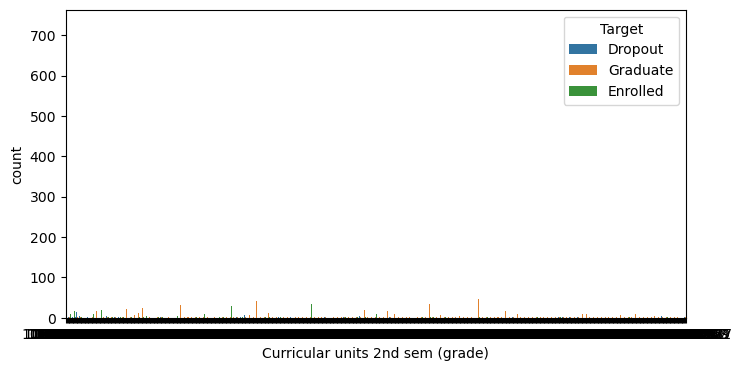

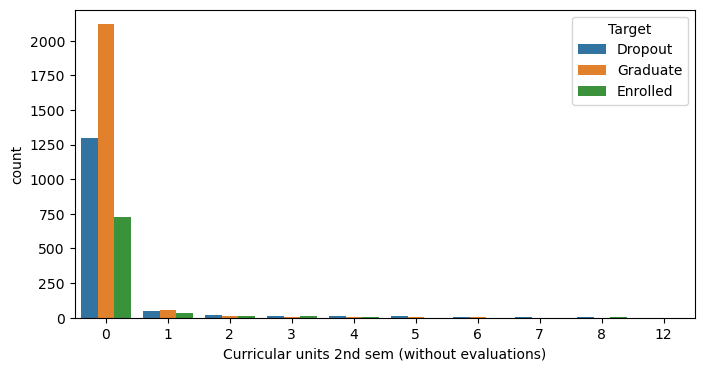

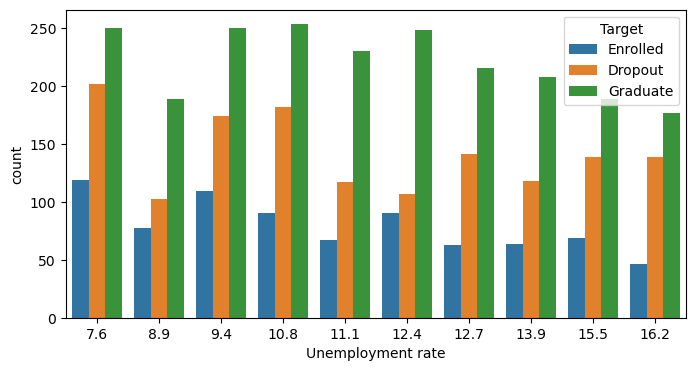

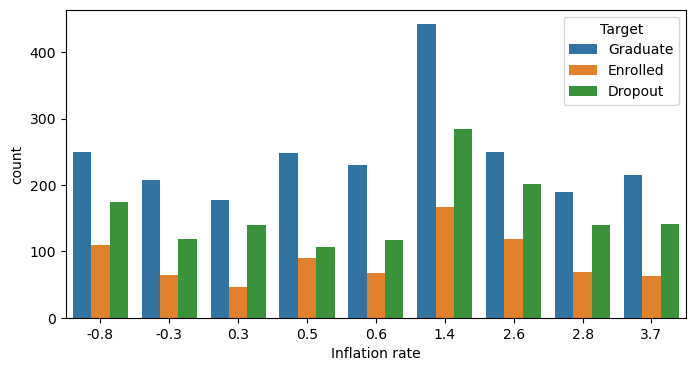

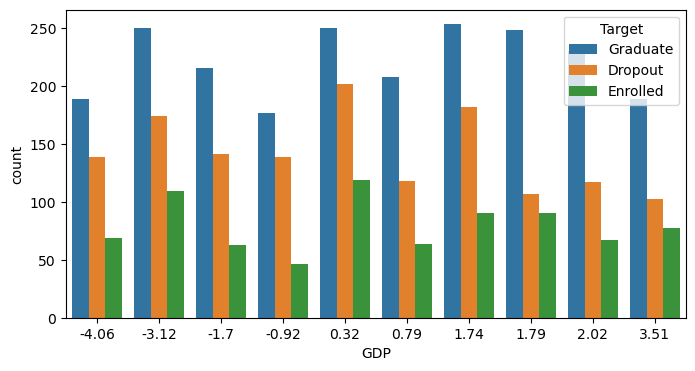

In [29]:
for x in X:
    plt.figure(figsize=(8,4))
    sns.countplot(x=x, hue='Target', data=df)

**better to look at histograms for the actual numeric variables**

<Axes: xlabel='Previous qualification (grade)', ylabel='Count'>

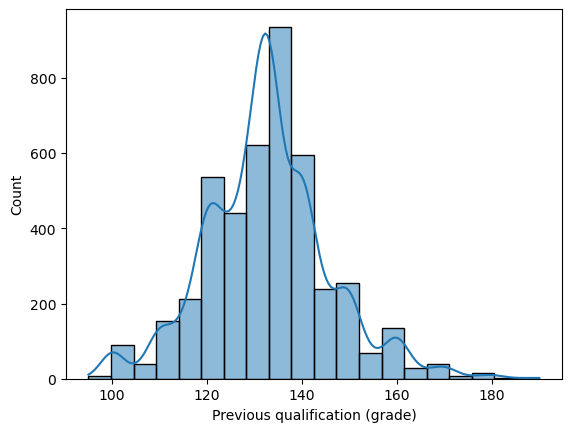

In [30]:
sns.histplot(data = df, x = 'Previous qualification (grade)', kde=True, bins=20)

<Axes: xlabel='Admission grade', ylabel='Count'>

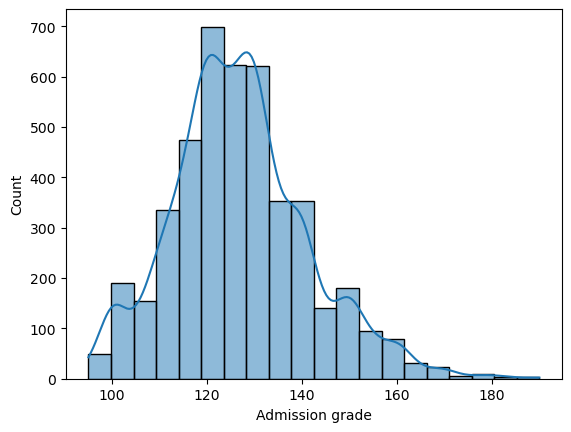

In [31]:
sns.histplot(data = df, x = 'Admission grade', kde=True, bins=20)

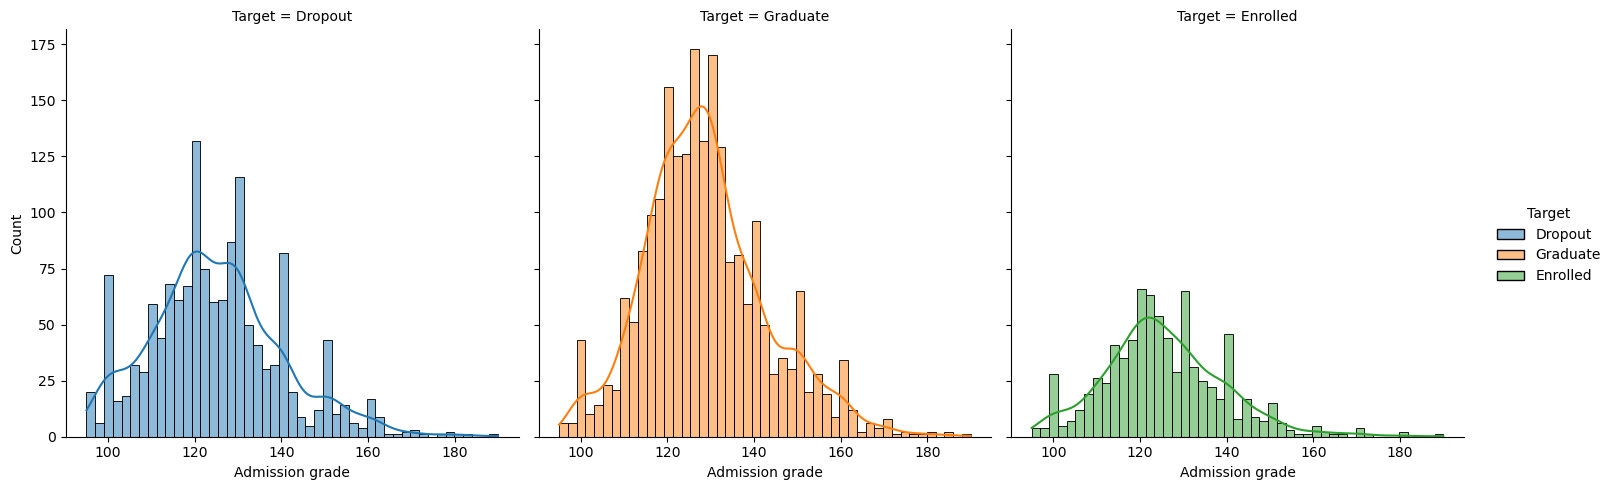

In [32]:
sns.displot(data=df, x = 'Admission grade', hue='Target', col='Target', kde=True)
plt.show()

<Axes: xlabel='Curricular units 1st sem (grade)', ylabel='Count'>

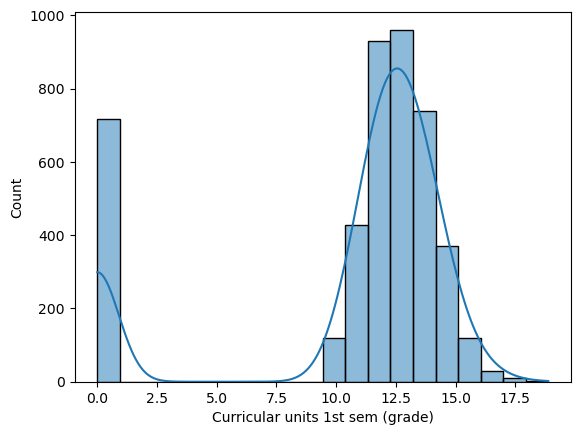

In [33]:
sns.histplot(data = df, x = 'Curricular units 1st sem (grade)', kde=True, bins=20)

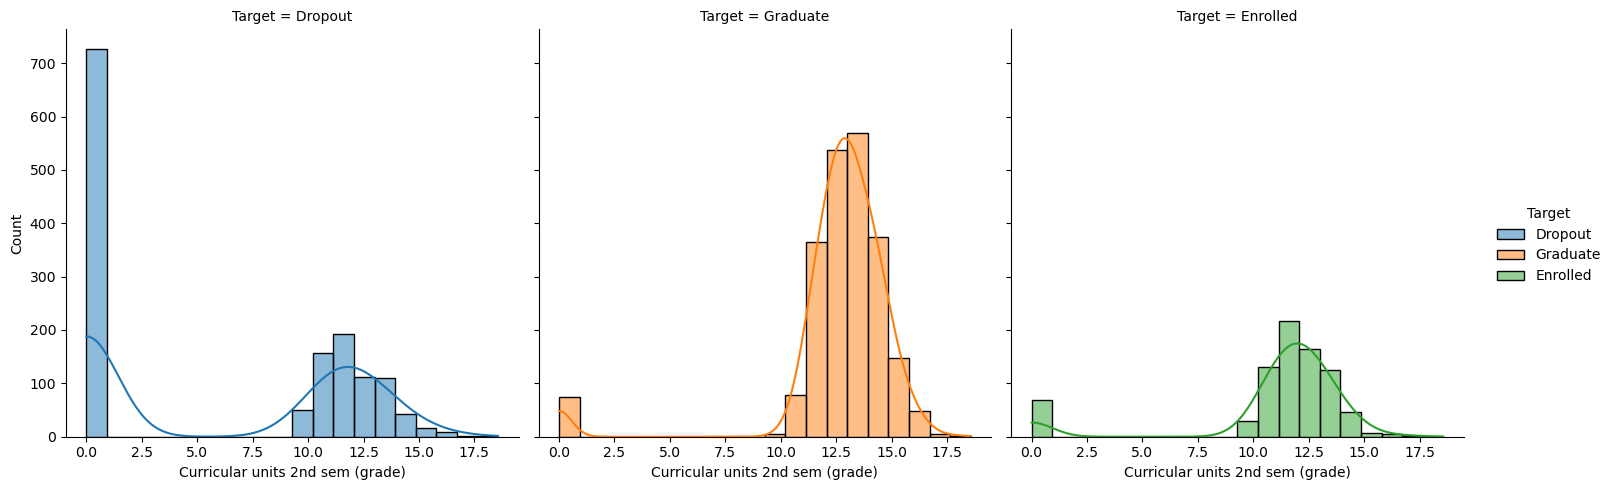

In [34]:
sns.displot(data = df, x = 'Curricular units 2nd sem (grade)', col='Target', hue='Target',kde=True, bins=20)

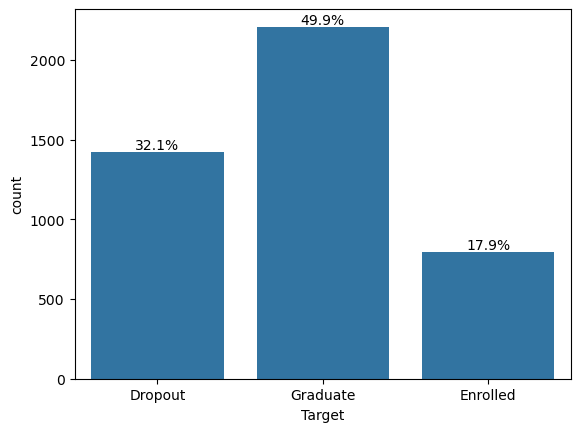

In [35]:
ax = sns.countplot(data = df, x='Target')
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = height/total * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')
plt.show()

**A lot of the variables are imbalanced**

<Axes: xlabel='Target', ylabel='Curricular units 2nd sem (grade)'>

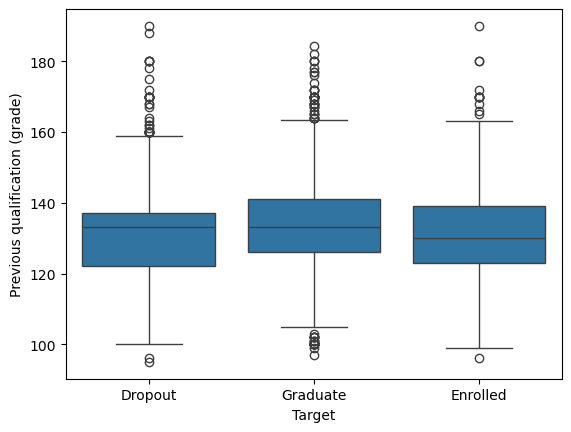

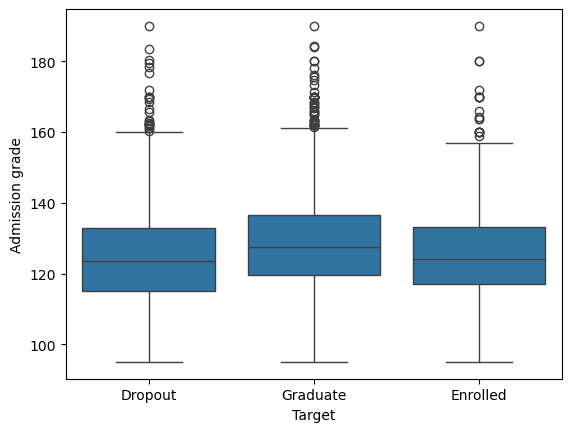

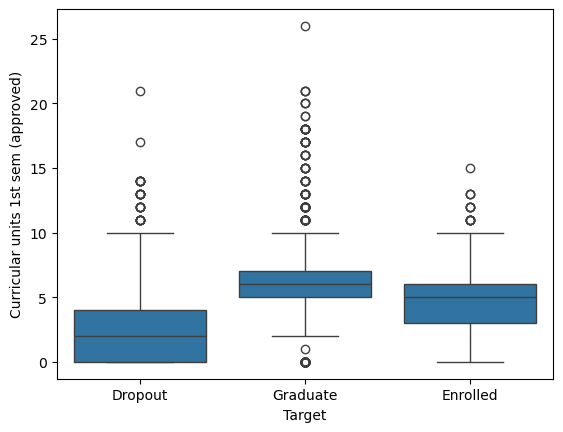

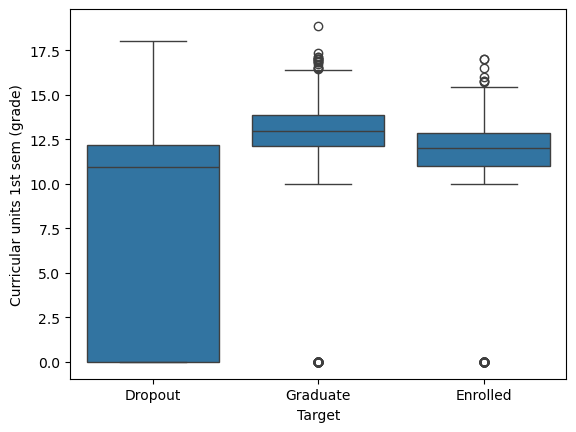

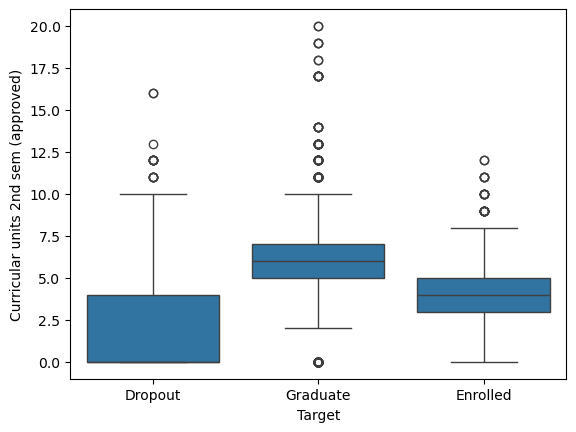

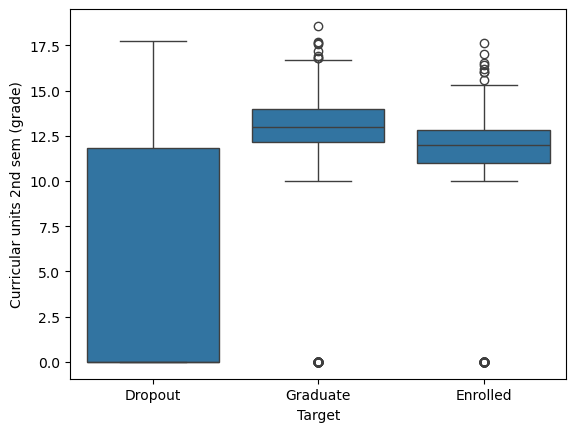

In [36]:
#looking at continuous academic variables
plt.figure()
sns.boxplot(x='Target', y = 'Previous qualification (grade)', data = df)
plt.figure()
sns.boxplot(x='Target', y = 'Admission grade', data = df)
plt.figure()
sns.boxplot(x='Target', y = 'Curricular units 1st sem (approved)', data = df)
plt.figure()
sns.boxplot(x='Target', y = 'Curricular units 1st sem (grade)', data = df)
plt.figure()
sns.boxplot(x='Target', y = 'Curricular units 2nd sem (approved)', data = df)
plt.figure()
sns.boxplot(x='Target', y = 'Curricular units 2nd sem (grade)', data = df)

- Students who got less curricular units approved in the 1st and 2nd semester are more likely to dropout
- Students with higher grades their 1st and 2nd semester are more likely to graduate and stay enrolled

<Axes: xlabel='Debtor', ylabel='count'>

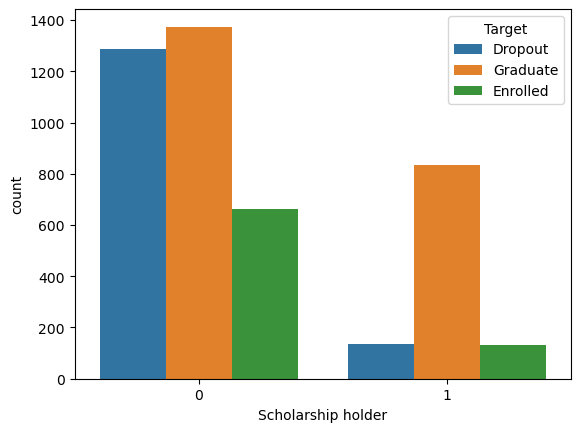

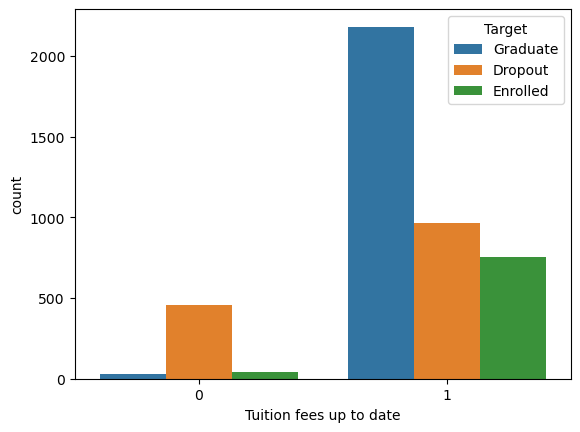

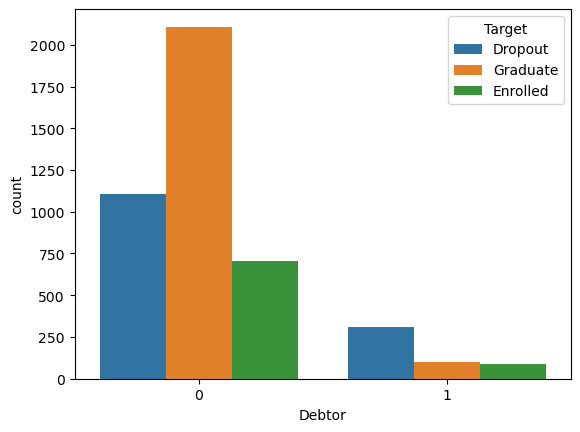

In [37]:
#financial factors vs target variables
plt.figure()
sns.countplot(x='Scholarship holder', hue='Target', data=df)
plt.figure()
sns.countplot(x='Tuition fees up to date', hue='Target', data=df)
plt.figure()
sns.countplot(x='Debtor', hue='Target', data=df)

- Students who have a scholarship are more likely to graduate while students who do noto have a scholarship are almost equally as likely to dropout than to graduate.
- Almost all students whose tuition fees are not up to date dropout
- Students who are debtors have a higher probability of dropping out while students not in debt are more likely to graduate

<Axes: xlabel='Marital Status', ylabel='count'>

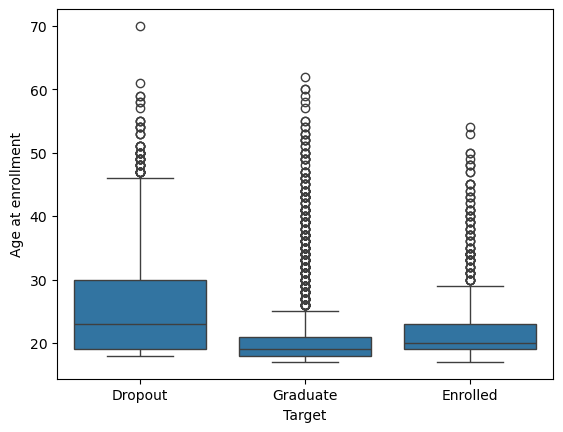

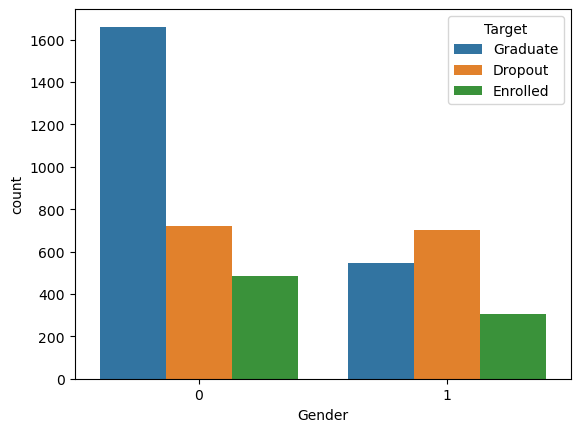

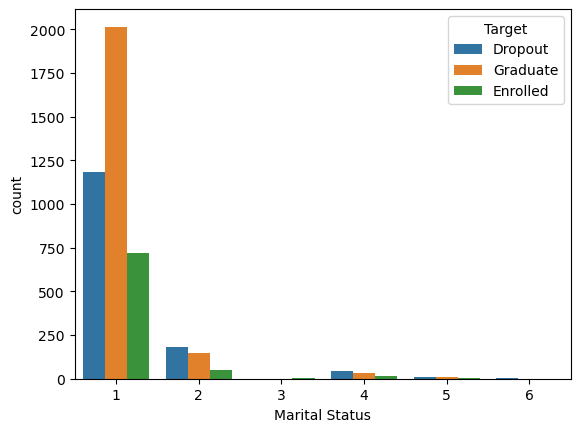

In [38]:
#demographics vs target variable
plt.figure()
sns.boxplot(x='Target', y = 'Age at enrollment', data = df)
plt.figure()
sns.countplot(x='Gender', hue = 'Target', data = df)
plt.figure()
sns.countplot(x='Marital Status', hue = 'Target', data = df)

- Older students dropout more
- Women have a higher probability of graduating while men are more likely to dropout
- Single people tend to graduate more while married and divorced students are slightly more likely to dropout

**Classification Models**

In [39]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution:\n{y['Target'].value_counts()}")

Features shape: (4424, 36)
Target shape: (4424, 1)

Class distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## Classification Modeling

We built and evaluated classification models to predict student outcomes (Dropout, Enrolled, Graduate). We implemented three models: Logistic Regression, Random Forest, and a Neural Network (MLP). Given the class imbalance observed in our EDA, we applied class weighting and evaluate using macro-averaged metrics.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Data Preparation

We encoded the target variable, split it into train/test sets (80/20), and scaled features for models sensitive to feature magnitude (Logistic Regression, MLP).

In [42]:
df_model = X.copy()
df_model['Target'] = y['Target'].values

# Encode target: Dropout=0, Enrolled=1, Graduate=2
le = LabelEncoder()
df_model['Target_encoded'] = le.fit_transform(df_model['Target'])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Features and target
X_model = df_model.drop(columns=['Target', 'Target_encoded'])
y_model = df_model['Target_encoded']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"\nClass distribution in training set:\n{y_train.value_counts().rename(index=dict(enumerate(le.classes_)))}")

Class mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Training set size: 3539
Test set size:     885

Class distribution in training set:
Target_encoded
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64


### Model 1: Logistic Regression

Logistic Regression served as our interpretable baseline. We used `class_weight='balanced'` to account for class imbalance and scale the features using StandardScaler.

Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.85      0.68      0.76       284
    Enrolled       0.41      0.64      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



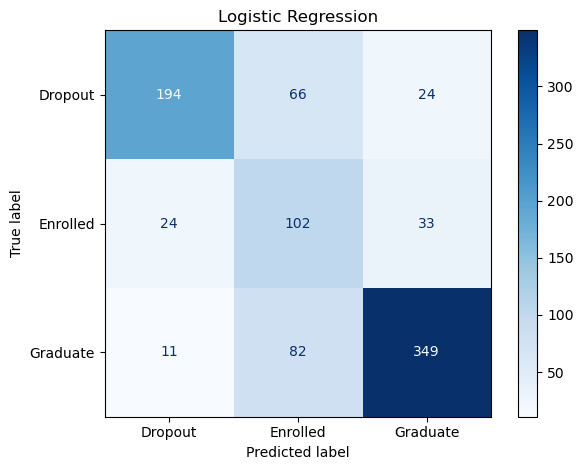

In [43]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
disp_lr.plot(cmap='Blues')
plt.title("Logistic Regression")
plt.tight_layout()
plt.show()

### Model 2: Random Forest

Random Forest is a method well-suited for data with mixed feature types. It is less sensitive to feature scaling and provides feature importance scores. We again used `class_weight='balanced'` to address class imbalance.

Random Forest
              precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
    Enrolled       0.59      0.35      0.44       159
    Graduate       0.79      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.68      0.70       885
weighted avg       0.76      0.78      0.76       885



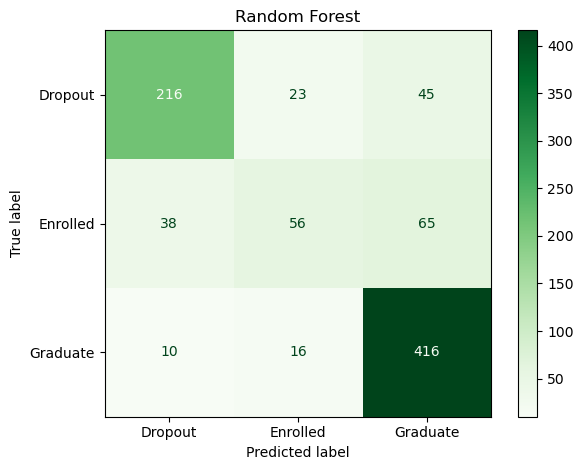

In [44]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Random Forest")
plt.tight_layout()
plt.show()

#### Random Forest: Feature Importance

One advantage of Random Forest is the ability to rank features by their contribution to classification decisions.

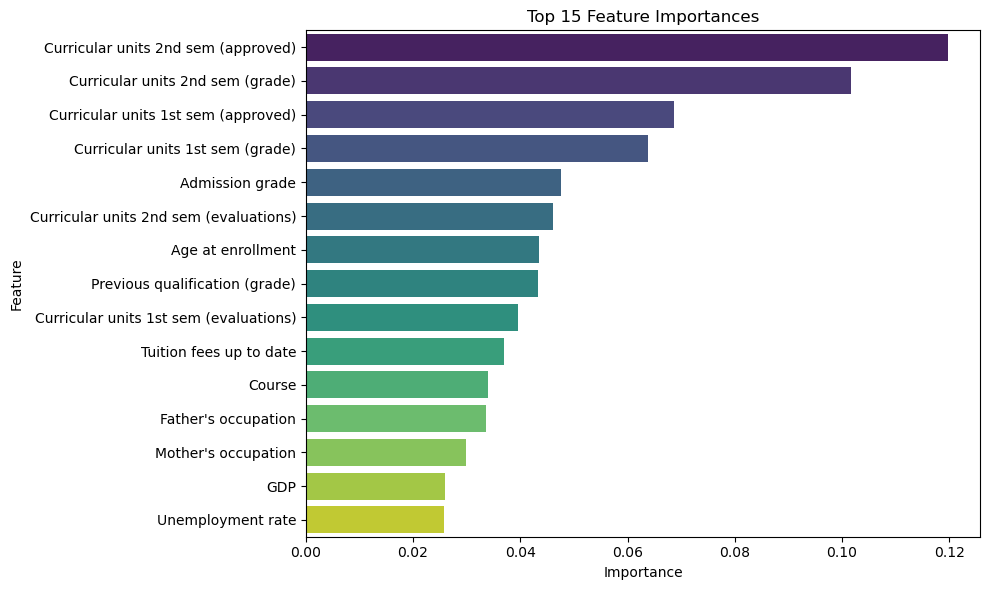

In [45]:
importances = rf.feature_importances_
feature_names = X_model.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

### Model 3: Neural Network (MLP)

We used the MLPClassifier (Multi-Layer Perceptron) with two hidden layers. Features are scaled, and we used early stopping to prevent overfitting.

Neural Network (MLP)
              precision    recall  f1-score   support

     Dropout       0.82      0.74      0.78       284
    Enrolled       0.45      0.41      0.43       159
    Graduate       0.80      0.88      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.68      0.68       885
weighted avg       0.75      0.75      0.75       885



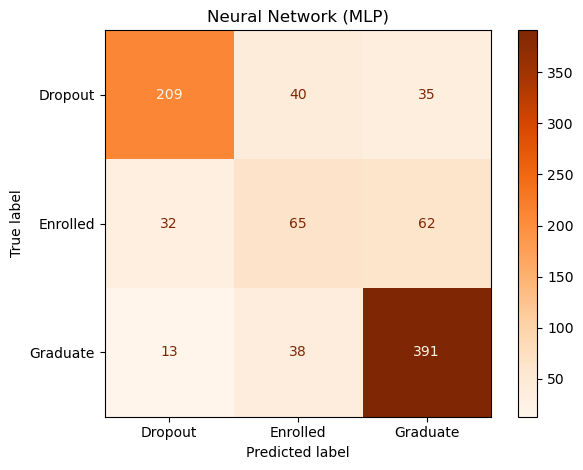

In [46]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("Neural Network (MLP)")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=le.classes_)
disp_mlp.plot(cmap='Oranges')
plt.title("Neural Network (MLP)")
plt.tight_layout()
plt.show()

### Model Comparison

We compared macro-averaged F1 scores across all three models to identify the best performer.

               Model  Macro F1 Score
       Random Forest        0.696257
 Logistic Regression        0.692742
Neural Network (MLP)        0.682758


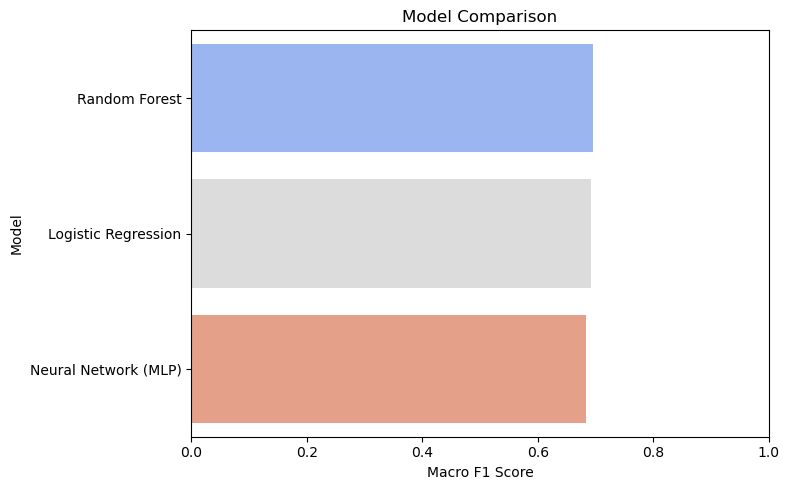

In [47]:
from sklearn.metrics import f1_score

models = ['Logistic Regression', 'Random Forest', 'Neural Network (MLP)']
f1_scores = [
    f1_score(y_test, y_pred_lr, average='macro'),
    f1_score(y_test, y_pred_rf, average='macro'),
    f1_score(y_test, y_pred_mlp, average='macro')
]

comparison_df = pd.DataFrame({'Model': models, 'Macro F1 Score': f1_scores})
comparison_df = comparison_df.sort_values('Macro F1 Score', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Macro F1 Score', y='Model', data=comparison_df, palette='coolwarm')
plt.xlim(0, 1)
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

In [48]:
!jupyter nbconvert --to pdf Final-Project-Team-5.ipynb

[NbConvertApp] Converting notebook Final-Project-Team-5.ipynb to pdf
[NbConvertApp] Support files will be in Final-Project-Team-5_files\
[NbConvertApp] Making directory .\Final-Project-Team-5_files
[NbConvertApp] Writing 109078 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | b had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1734299 bytes to Final-Project-Team-5.pdf
